In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import random
import time

import sys, os, pathlib
REPO_DIR = pathlib.Path(os.path.dirname(os.path.abspath(os.getcwd()))); print(f"Repo: {str(REPO_DIR)}")
sys.path.insert(0, str(REPO_DIR / "src"))

from paths import *
from traffic_sim import *
from optimization_utils import *
from param_loader import METANET_Params
from viz import Plotter

Repo: /Users/tristanchaang/MIT/UROP-Traffic/mpc-traffic-flow


In [4]:
def format_time(start_hour, minutes):
    hour, minute = divmod(int(start_hour * 60 + minutes), 60)
    return f"{hour % 24:02d}:{minute:02d}"

In [5]:
real_data = True

if real_data:
    # #### I-24 Data
    DATE = "11_28"
    i24_data_path = REPO_DIR / "data" / "i24" / f"i24_{DATE}"

    q_hat: time_space = np.load(i24_data_path / "q_hat.npy")#[240:270, :]
    p_hat: time_space = np.load(i24_data_path / "rho_hat.npy")#[240:270, :]

    lane_map = np.load(i24_data_path / "lane_mapping.npy")
    lane_mapping = {i: float(lane_map[i+1]) for i in range(len(lane_map)-2)}
    ramp_mapping = {"on_ramps": np.load(i24_data_path / "on_ramp_mapping.npy")[1:-1], "off_ramps": np.load(i24_data_path / "off_ramp_mapping.npy")[1:-1]}

    print("on_ramps:", list(map(int, ramp_mapping["on_ramps"])))
    print("off_ramps:", list(map(int, ramp_mapping["off_ramps"])))
    print("lanes:", list(map(lambda x: round(x, 2), lane_mapping.values())))
else:
    q_hat: time_space = np.load(REPO_DIR / "data" / "q_synthetic.npy") #np.load("data/flow_10sec_400m_1hr.npy")
    p_hat: time_space = np.load(REPO_DIR / "data" / "p_synthetic.npy") #np.load("data/density_10sec_400m_1hr.npy")

p_hat: time_space = np.clip(p_hat, 1e-3, None)
q_hat: time_space = np.clip(q_hat, 1e-3, None)
v_hat = q_hat / p_hat
flattened_q_hat = q_hat.flatten()
print(f"{flattened_q_hat.max() = }")
flattened_rho_hat = p_hat.flatten()
C_i = np.mean(np.sort(flattened_q_hat)[-5:]) # largest 5 values of q_hat, averaged
print(f"{C_i = }")
K = len(flattened_rho_hat)
print(f"{K = }")

on_ramps: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1]
off_ramps: [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0]
lanes: [4.0, 4.0, 4.0, 4.35, 5.0, 5.0, 5.0, 5.0, 4.86, 4.0, 4.0, 4.05, 4.51, 4.0]
flattened_q_hat.max() = 8091.98009999998
C_i = 7532.372340000019
K = 5760


In [6]:
if not real_data:
    downstream_density = np.full(p_hat.shape[0], 0)
    data_inflow = np.array([5500 if i in range(20, 20 + 90) else 4000 for i in range(p_hat.shape[0])])
    np.save(REPO_DIR / "data" / "downstream_density_synthetic.npy", downstream_density)
    np.save(REPO_DIR / "data" / "inflow_synthetic.npy", data_inflow)
    p = Plotter(2, 1, figsize=(10, 5))
    p[0].plot(downstream_density, label="Downstream Density")
    p[1].plot(data_inflow, label="Upstream Inflow")
    p.show()

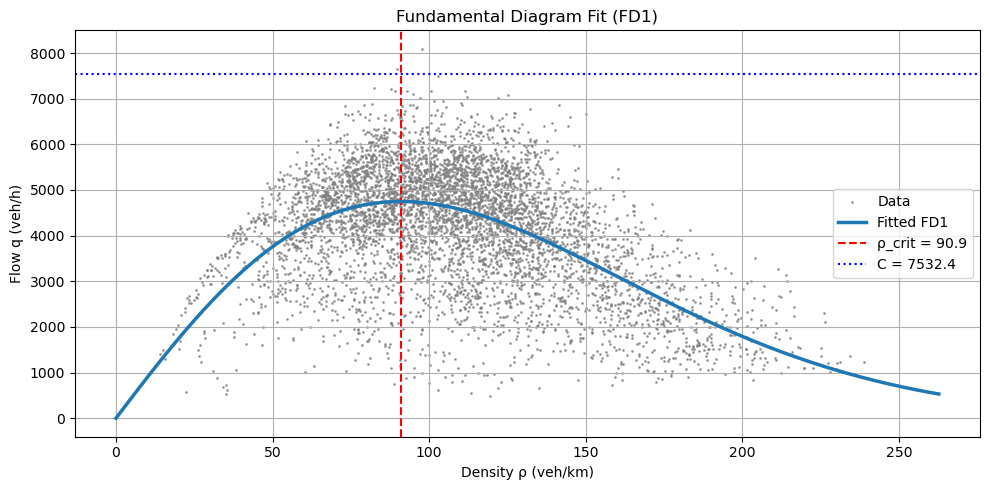

{'rho_crit': 90.9089566919478, 'V_free': 90.32182804407725, 'a': 1.8254228618304158, 'C': 7532.372340000019, 'Q_fd1': <function fit_fd1.<locals>.Q_fd1 at 0x12fad8700>}


In [7]:
params = fit_fd1(flattened_rho_hat, flattened_q_hat)
print(params)

In [8]:
print(f"Bounds on rho: {p_hat.min()} to {p_hat.max()}")
print(f"Bounds on q: {q_hat.min()} to {q_hat.max()}")
print(f"Bounds on v: {v_hat.min()} to {v_hat.max()}")

Bounds on rho: 14.00999575 to 238.81997374999997
Bounds on q: 493.0839000000909 to 8091.98009999998
Bounds on v: 4.099431208657852 to 116.22656577073002


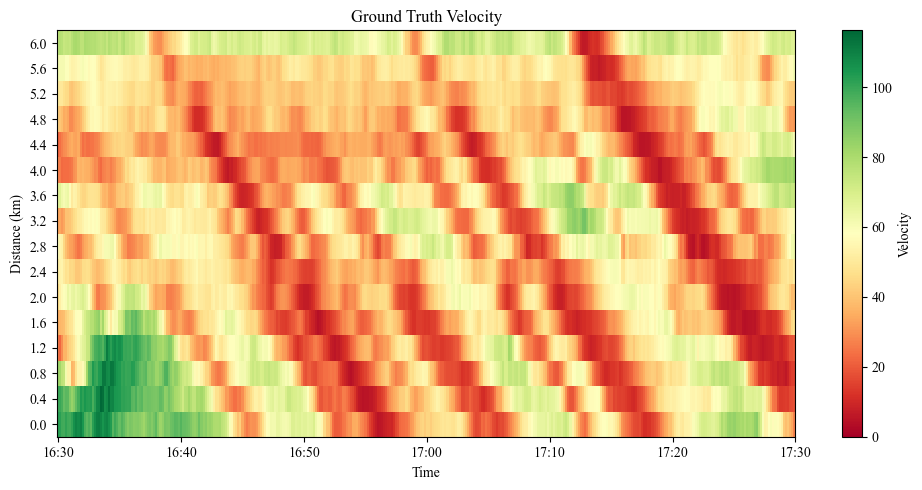

In [9]:
start_wallclock_time = 16.5

# Convert time steps to wall clock time
time_steps = v_hat.shape[0]+1
time_ticks = list(range(0, time_steps, int(time_steps / 6)))
# Correct - each step is 10 seconds = 10/60 minutes
tick_minutes = [i * 10 / 60 for i in time_ticks]
time_labels = [format_time(start_wallclock_time, m) for m in tick_minutes]

# Convert space steps to km
space_steps = v_hat.shape[1]
space_labels = [f"{(i * 400) / 1000:.1f}" for i in range(0, space_steps, int(space_steps / 10))]
space_ticks = list(range(0, space_steps, int(space_steps / 10)))

p = Plotter(1, 1)
p.fig.colorbar(p[0].imshow(v_hat.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none", vmin=0),
  label="Velocity")
p[0] = {'title': 'Ground Truth Velocity', 'xlabel': 'Time', 'ylabel': 'Distance (km)',
        'xticks': time_ticks, 'xticklabels': time_labels, 'yticks': space_ticks, 'yticklabels': space_labels}
p.show()

In [10]:
T = 10 / 3600
l = 0.4
num_calibrated_segments = v_hat.shape[1] - 2
include_ramping = True
varylanes = False
smoothing = True

In [11]:
random.seed(1)
np.random.seed(1)
# lane_mapping = np.array([4 if i < num_calibrated_segments - 4 else 2 for i in range(num_calibrated_segments)])
RESULTS_DIR = ensure_dir(i24_data_path / DEFAULT_CALIBRATION)

#"calibration_results/synthetic_test" if not real_data else "calibration_results/robust_S10_mean" #"calibration_results_i35/test_sb2"
# boundary_conditions = {
#     "initial_flow": data_inflow,
#     "downstream_density": downstream_density,
# }

#robust_opt_params = RobustOptConfig(S=5, bc_noise_percent=0.0001, seed=2, objective_mode="mean")
start = time.time()
results = run_calibration(
    p_hat,
    q_hat,
    T,
    l,
    num_calibrated_segments=num_calibrated_segments,
    # sep_boundary_conditions=boundary_conditions,
    varylanes=varylanes,
    #lane_mapping={0:4, 1:4, 24, 3:4.5, 4:5, 5:5, 6:5, 7:5, 8:5, 9:4, 10:4, 11:4, 12:4.5, 13:4},
    include_ramping=include_ramping,
    lane_mapping=lane_mapping,
    ramp_mapping=ramp_mapping,
    smoothing=smoothing,
    constraint_tol=1e-12,
    warmstart= None, #"calibration_results/robust_S10_0001",
    robust_opt=None,
    time_varying_ramps=False,
    fixed_inflows=None
)

print("Calibration took", time.time() - start, "seconds")

seg 0 is not an off-ramp, fixing beta to 1e-3
seg 1 is not an off-ramp, fixing beta to 1e-3
seg 2 is not an off-ramp, fixing beta to 1e-3
seg 3 is not an off-ramp, fixing beta to 1e-3
seg 4 is not an off-ramp, fixing beta to 1e-3
seg 5 is not an off-ramp, fixing beta to 1e-3
seg 6 is not an off-ramp, fixing beta to 1e-3
seg 7 is not an off-ramp, fixing beta to 1e-3
seg 8 is not an off-ramp, fixing beta to 1e-3
seg 10 is not an off-ramp, fixing beta to 1e-3
seg 12 is not an off-ramp, fixing beta to 1e-3
seg 13 is not an off-ramp, fixing beta to 1e-3
Ipopt 3.14.20: max_iter=20000
acceptable_constr_viol_tol=1e-12
constr_viol_tol=1e-12


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
****************************************************

In [12]:
{l: (v.shape if isinstance(v, np.ndarray) else v) for l, v in results.items()}

{'v_pred': (360, 14),
 'rho_pred': (360, 14),
 'tau': (14,),
 'K': (14,),
 'eta_high': (14,),
 'rho_crit': (14,),
 'v_free': (14,),
 'a': (14,),
 'num_lanes': (14,),
 'beta': (14,),
 'r_inflow': (14,),
 'obj_val': 1369.8577529835327,
 'solver_status': 'ok',
 'termination_condition': 'optimal'}

In [13]:
np.save(RESULTS_DIR/"upstream_flow.npy", smooth_inflow(q_hat[:, 0]) if smoothing else q_hat[:, 0])
np.save(RESULTS_DIR/"downstream_density.npy", smooth_inflow(p_hat[:, -1]) if smoothing else p_hat[:, -1])

In [14]:
tau_array = results["tau"]
K_array = results["K"]
eta_high_array = results["eta_high"]
rho_crit_array = results["rho_crit"]
v_free_array = results["v_free"]
a_array = results["a"]
num_lanes_array = results["num_lanes"]
# if include_ramping:
    # gamma_array = results["gamma"]
beta_array = results["beta"]
r_inflow_array = results["r_inflow"]

In [15]:
# r_array = np.zeros(num_calibrated_segments)
# beta_array = np.zeros(num_calibrated_segments)
# print(beta_array.shape)
# print(r_inflow_array.shape)

In [16]:
# Save everything
tau_array = results["tau"]
K_array = results["K"]
eta_high_array = results["eta_high"]
rho_crit_array = results["rho_crit"]
v_free_array = results["v_free"]
a_array = results["a"]
num_lanes_array = results["num_lanes"]
# if include_ramping:
    # gamma_array = results["gamma"]
beta_array = results["beta"]
r_inflow_array = results["r_inflow"]
v_pred_array = results["v_pred"]
rho_pred_array = results["rho_pred"]
q_array = v_pred_array * rho_pred_array

np.save(f"{RESULTS_DIR}/tau.npy", tau_array)
np.save(f"{RESULTS_DIR}/K.npy", K_array)
np.save(f"{RESULTS_DIR}/eta_high.npy", eta_high_array)
np.save(f"{RESULTS_DIR}/rho_crit.npy", rho_crit_array)
np.save(f"{RESULTS_DIR}/v_free.npy", v_free_array)
np.save(f"{RESULTS_DIR}/a.npy", a_array)
np.save(f"{RESULTS_DIR}/num_lanes.npy", num_lanes_array)
np.save(f"{RESULTS_DIR}/q_pred.npy", q_array)
np.save(f"{RESULTS_DIR}/v_pred.npy", v_pred_array)
np.save(f"{RESULTS_DIR}/rho_pred.npy", rho_pred_array)
# np.save("r_array.npy", r_array)
# if include_ramping:
    # np.save("gamma_array.npy", gamma_array)
np.save(f"{RESULTS_DIR}/beta_array.npy", beta_array)
np.save(f"{RESULTS_DIR}/r_inflow_array.npy", r_inflow_array)

(360, 14)
(360, 14)
(360, 16)
14


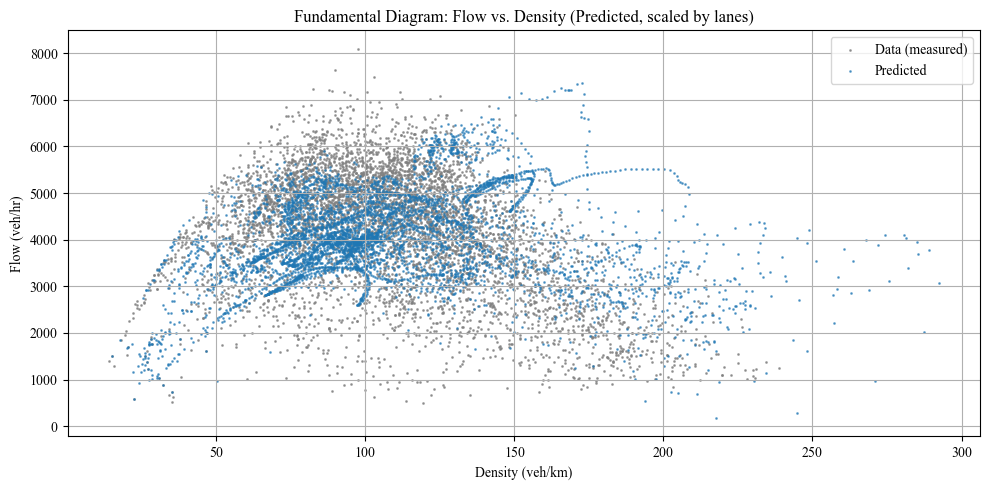

In [17]:
import matplotlib.pyplot as plt

# # Collect scaled predictions across all segments
all_rho_pred = rho_pred_array

print(all_rho_pred.shape)
all_v_pred = v_pred_array
all_q_pred = all_rho_pred * all_v_pred

# Stack predictions
all_rho_pred = np.hstack(all_rho_pred)
all_q_pred = np.hstack(all_q_pred)
all_v_pred = np.hstack(all_v_pred)

print(v_pred_array.shape)
print(v_hat.shape)
print(len(tau_array))

# assert np.all(v_pred_array[0,:] == v_hat[0,1:-1])
# assert np.all(v_pred_array[0,:] == v_hat[0,1:-1])
# Plot
p = Plotter(1, 1)
p[0].scatter(p_hat, q_hat, color="gray", alpha=0.7, s=1, label="Data (measured)")
p[0].scatter(all_rho_pred, all_q_pred, alpha=0.6, s=1, label="Predicted")
p[0] = {'xlabel': "Density (veh/km)", 'ylabel': "Flow (veh/hr)", 'title': "Fundamental Diagram: Flow vs. Density (Predicted, scaled by lanes)"}
p[0].grid()
p.show()

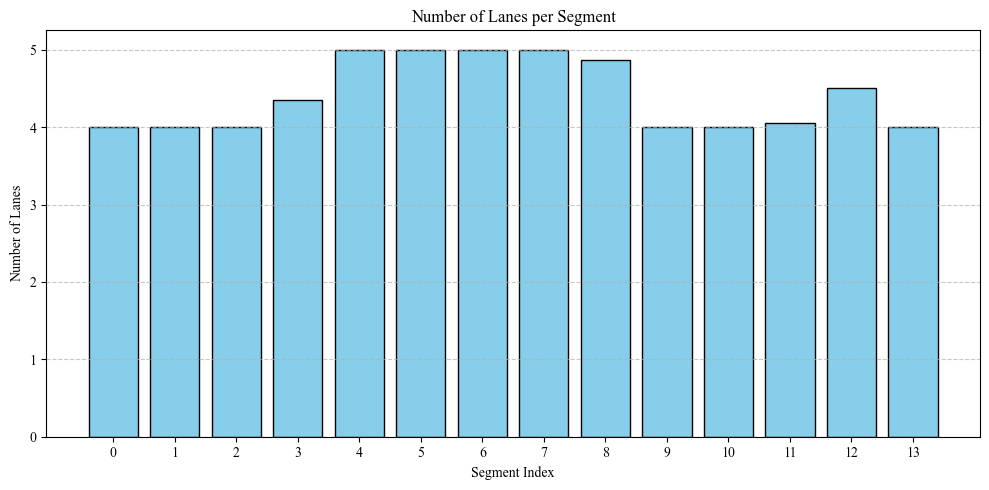

In [18]:
p = Plotter(1, 1)
p[0].bar(np.arange(len(num_lanes_array)), num_lanes_array, color="skyblue", edgecolor="black")
p[0] = {'xlabel': "Segment Index", 'ylabel': "Number of Lanes", 'title': "Number of Lanes per Segment",
        'xticks': np.arange(len(num_lanes_array))}
p[0].grid(axis="y", linestyle="--", alpha=0.7)
p.show()

In [19]:
# Read parameters from RESULTS_DIR

# RESULTS_DIR = "ga_calibration_results/trials2500"


tau_array = np.load(f"{RESULTS_DIR}/tau.npy")
K_array = np.load(f"{RESULTS_DIR}/K.npy")
eta_high_array = np.load(f"{RESULTS_DIR}/eta_high.npy")
v_free_array = np.load(f"{RESULTS_DIR}/v_free.npy")
rho_crit_array = np.load(f"{RESULTS_DIR}/rho_crit.npy")
a_array = np.load(f"{RESULTS_DIR}/a.npy")

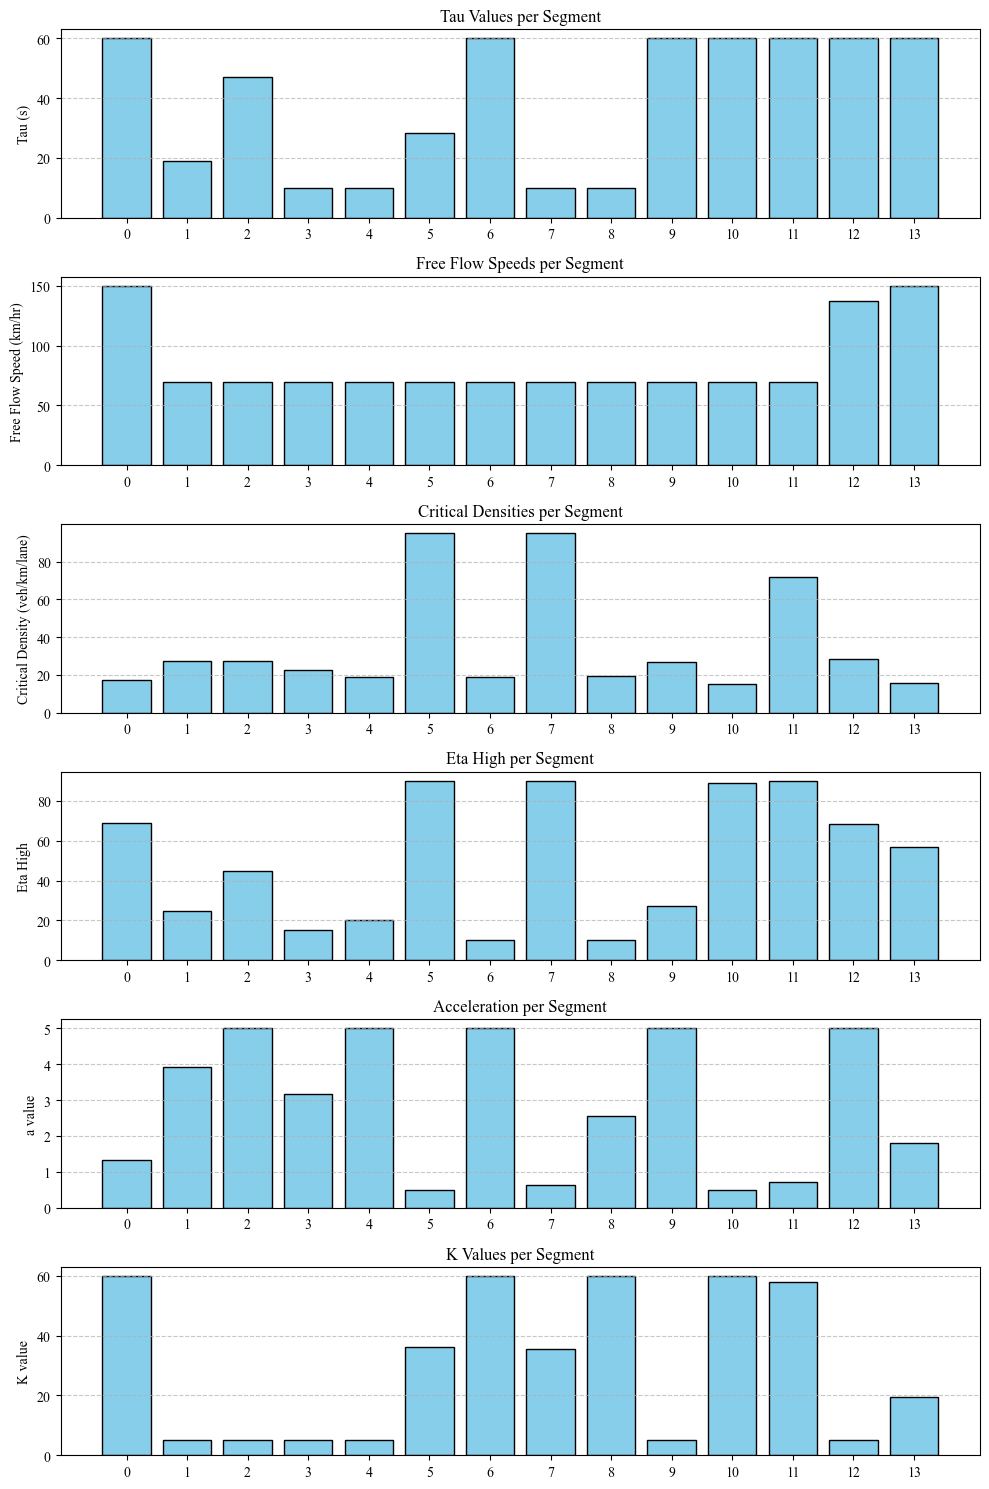

In [20]:
# Plot parameters in bar chart, show default value
p = Plotter(6, 1, figsize=(10, 15))
for i, array in enumerate([tau_array*3600, v_free_array, rho_crit_array, eta_high_array, a_array, K_array]):
    p[i].bar(np.arange(len(array)), array, color="skyblue", edgecolor="black")
    p[i] = {'ylabel': f"{['Tau (s)', 'Free Flow Speed (km/hr)', 'Critical Density (veh/km/lane)', 'Eta High', 'a value', 'K value'][i]}",
            'title': f"{['Tau Values', 'Free Flow Speeds', 'Critical Densities', 'Eta High', 'Acceleration', 'K Values'][i]} per Segment",
            'xticks': np.arange(len(array))}
    p[i].grid(axis="y", linestyle="--", alpha=0.7)
p.show()

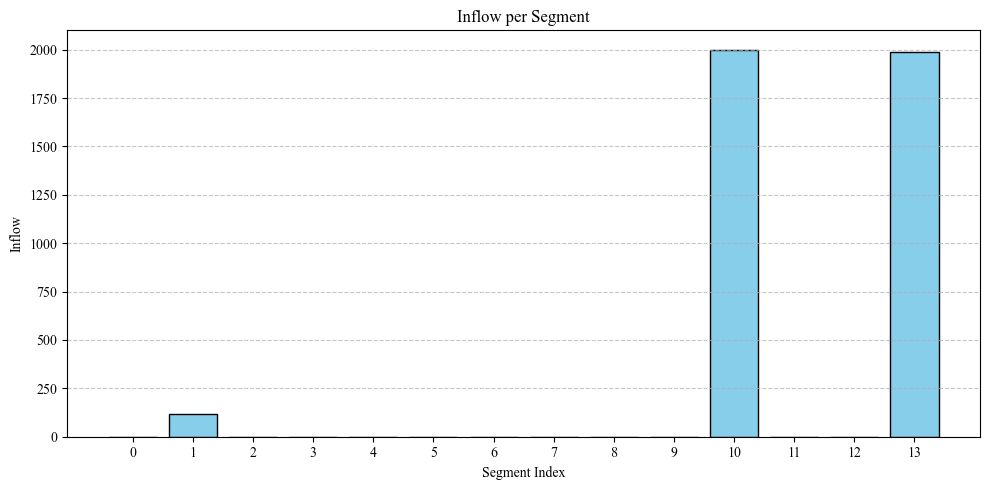

In [21]:
if include_ramping:
  p = Plotter(1, 1)
  p[0].bar(np.arange(len(r_inflow_array)), r_inflow_array, color="skyblue", edgecolor="black")
  p[0] = {'xlabel': "Segment Index", 'ylabel': "Inflow", 'title': "Inflow per Segment",
          'xticks': np.arange(len(r_inflow_array))}
  p[0].grid(axis="y", linestyle="--", alpha=0.7)
  p.show()

In [22]:
# print(all_v_pred.shape)
q_array = rho_pred_array * v_pred_array
def mape(y_true, y_pred): return np.mean(np.abs((y_true - y_pred) / y_true) * 100)
def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred) ** 2))
for qt, y, y_pred in [('Velocity', v_hat[:, 1:-1], v_pred_array), ('Density', p_hat[:, 1:-1], rho_pred_array), ('Flow', q_hat[:, 1:-1], q_array)]:
  print(f"{qt+':':<8}\t (mape {round(mape(y, y_pred), 2)} %, rmse {round(rmse(y, y_pred), 2)})")


Velocity:	 (mape 34.51 %, rmse 13.03)
Density:	 (mape 24.86 %, rmse 34.26)
Flow:   	 (mape 30.61 %, rmse 1204.48)


In [23]:
print("Simulating with calibrated parameters...")
# stop printing in scientific notation
# RESULTS_DIR = "ga_calibration_results"
np.set_printoptions(suppress=True)
# RESULTS_DIR = "robust_mpc_calibration_results/S5/control_h_10/params_1"
#RESULTS_DIR = "calibration_results_i35/shorter_nb"
#RESULTS_DIR = "mpc_calibration_results/control_h_360/params_1"

# RESULTS_DIR = "calibration_results/i24_11_30_rl_posttrain_2"
# RESULTS_DIR = "itsc_final/calibration_results/OCP"
# RESULTS_DIR = "itsc_final/mpc_calibration_results/control_h_90"
# RESULTS_DIR = "/Users/shreyaar/Desktop/PhD/research/MPC/data/i24/i24_11_21/calibration_static/fixed_ramping"
T=10/3600
l=0.4
num_calibrated_segments = p_hat.shape[1] - 2
# num_lanes_array = np.load(f"{RESULTS_DIR}/num_lanes.npy")

# Scale densities per lane for simulation
# num_lanes_array = np.load(f"{RESULTS_DIR}/num_lanes.npy")
scaled_rho_hat = p_hat[:, 1:-1] / lane_map[1:-1]#np.array(num_lanes_array)


# if smoothing boundary conditions
# print(num_lanes_array)
downstream_density = smooth_inflow(p_hat[:, -1]) / lane_map[1:-1][-1]
data_inflow: time_vec = smooth_inflow(q_hat[:, 0])
# downstream_density = rho_hat[:, -1] / num_lanes_array[-1]
# data_inflow = q_hat[:, 0]
# print(downstream_density[250:270])
# print(rho_hat[250:270, -1])

# Sim requires tuple of initial conditions: density, velocity, inflow, and queue
init_traffic_state = (scaled_rho_hat[0, :], v_hat[0, 1:-1], data_inflow[0], 0)
# print(RESULTS_DIR)

params = METANET_Params(path=RESULTS_DIR, num_segments=num_calibrated_segments).get_params()

simulator = METANET_Simulator(T=T, l=l, params=params, lanes=lane_mapping, real_data=True)

rho_sim, v_sim, _, tts_sim = simulator.run_with_history(
    demand = data_inflow,
    downstream_density = downstream_density,
    init_traffic_state = MetanetState(scaled_rho_hat[0, :], v_hat[0, 1:-1], data_inflow[0], 0),
    vsl_speeds = None
)


Simulating with calibrated parameters...


In [24]:
# good_params = METANET_Params(path=RESULTS_DIR, num_segments=num_calibrated_segments).get_params()
# bad_params = METANET_Params(path='calibration_results', num_segments=num_calibrated_segments).get_params()
# #check if params are different
# print(bad_params['r'])
# print(good_params['r'])
# for key in bad_params:
#     if isinstance(bad_params[key], dict):
#         for subkey in bad_params[key]:
#             if not np.array_equal(bad_params[key][subkey], good_params[key][subkey]):
#                 print(f"Parameter {key}[{subkey}] differs between bad and good params.")
#     else:
#         if not np.array_equal(bad_params[key], good_params[key]):
#             print(f"Parameter {key} differs between bad and good params.")


Pred shape: (360, 14)
True shape: (360, 14)
Max true density: 238.81997374999997


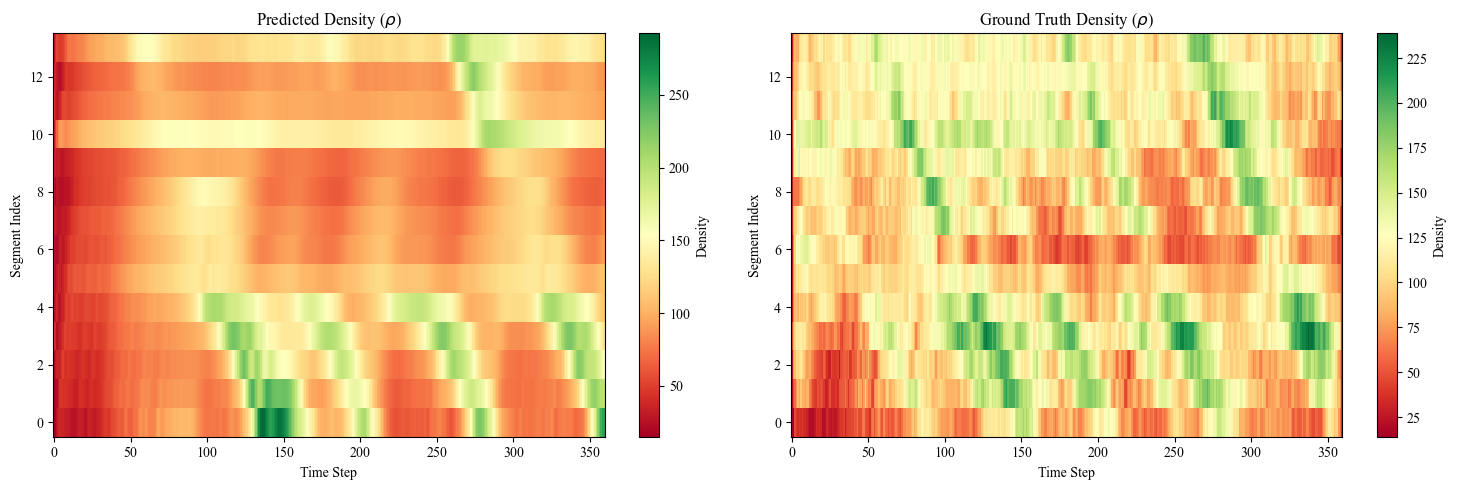

In [25]:
rho_plot_pred = rho_pred_array
rho_plot_true = p_hat[:, 1:-1]

print("Pred shape:", rho_plot_pred.shape)
print("True shape:", rho_plot_true.shape)
print("Max true density:", np.max(rho_plot_true))

p = Plotter(1, 2)
p.fig.colorbar(p[0].imshow(rho_plot_pred.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"), label="Density")
p[0] = {'title': 'Predicted Density ($\\rho$)', 'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
p.fig.colorbar(p[1].imshow(rho_plot_true.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"), label="Density")
p[1] = {'title': 'Ground Truth Density ($\\rho$)', 'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
p.show()

Pred shape: (360, 14)
True shape: (360, 14)
Max true density: 116.22656577073002


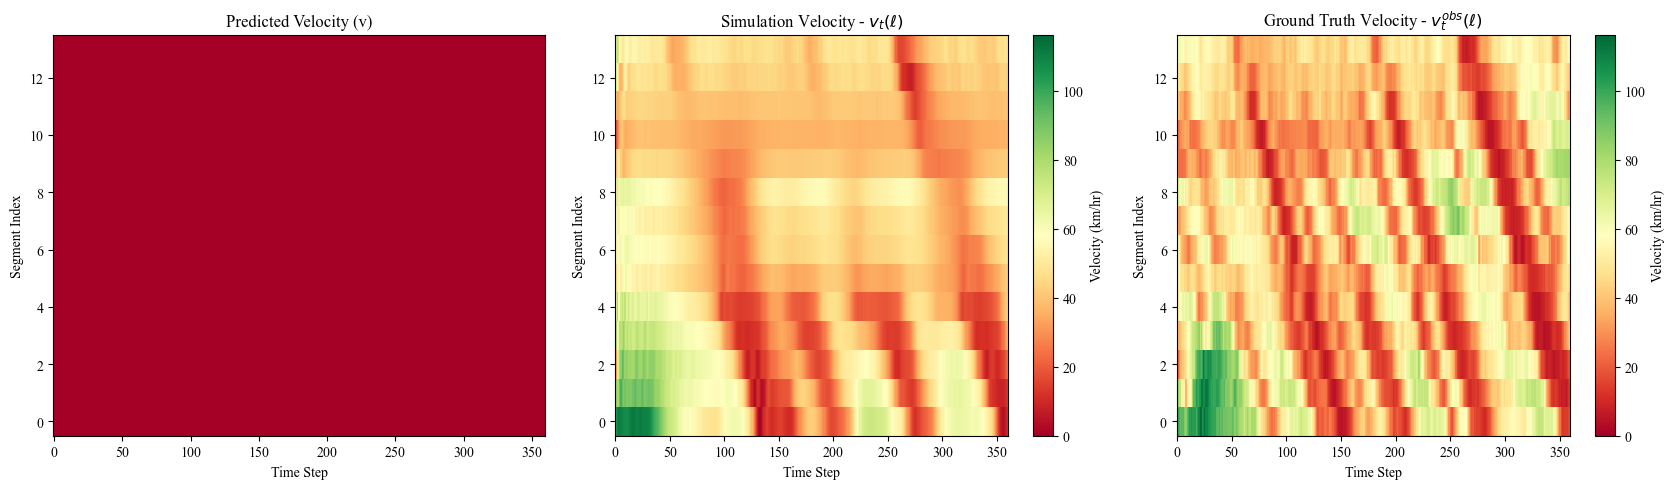

In [26]:
# print(v_pred_array[0, :])
# print(v_pred_array[1, :])
v_plot_pred = np.zeros_like(v_hat[:, 1:-1])#np.load(f"{RESULTS_DIR}/v_pred.npy")
v_plot_true = v_hat[:, 1:-1]

print("Pred shape:", v_plot_pred.shape)
print("True shape:", v_plot_true.shape)
print("Max true density:", np.max(v_plot_true))

vmin = min(v_plot_pred.min(), v_sim.min(), v_plot_true.min())
vmax = max(v_plot_pred.max(), v_sim.max(), v_plot_true.max())

# ---- One shared colorbar in its own axis ----
p = Plotter(1, 3)
p[0].imshow(v_plot_pred.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none", vmin=vmin, vmax=vmax)
p.fig.colorbar(p[1].imshow(v_sim.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none", vmin=vmin, vmax=vmax), label="Velocity (km/hr)")
p.fig.colorbar(p[2].imshow(v_plot_true.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none", vmin=vmin, vmax=vmax), label="Velocity (km/hr)")
p[0] = {'title': 'Predicted Velocity (v)', 'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
p[1] = {'title': 'Simulation Velocity - $v_t(\\ell)$', 'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
p[2] = {'title': 'Ground Truth Velocity - $v^{obs}_t(\\ell)$', 'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
p.show()

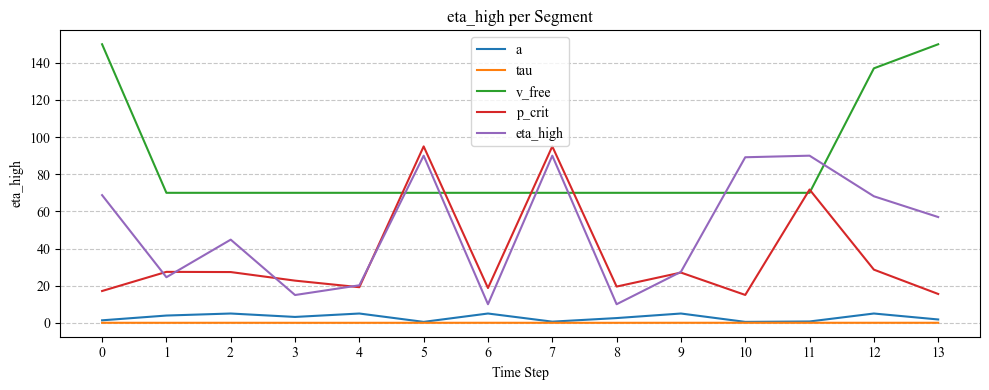

In [27]:
p = Plotter(1, 1, figsize=(10, 4))
for param in ['a', 'tau', 'v_free', 'p_crit', 'eta_high']:
    param_array = params[param][:]
    p[0].plot(np.arange(len(param_array)), param_array, label=param)
    p[0] = {'title': f"{param} per Segment", 'xlabel': "Time Step", 'ylabel': param,
            'xticks': np.arange(len(param_array))}
p[0].grid(axis="y", linestyle="--", alpha=0.7)
p.show()

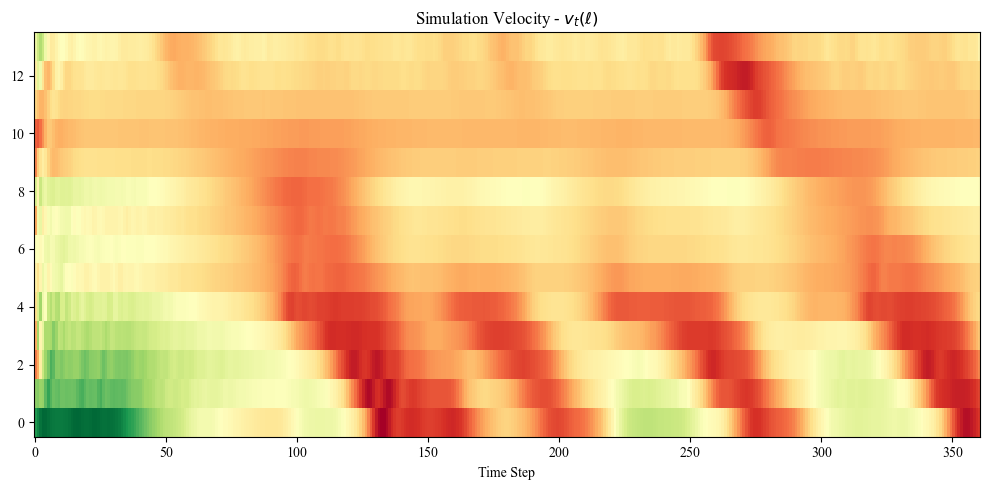

In [28]:
# Plot only v_sim
# --- Simulation ---
p = Plotter(1, 1)
p[0].imshow(v_sim.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none")
p[0].set_xlabel("Time Step")
p[0].set_title("Simulation Velocity - $v_t(\\ell)$")
p.show()

In [29]:
np.save(f"{RESULTS_DIR}/v_sim.npy", v_sim)

In [30]:
for l, mat_hat, mat_true in [
  ('p', p_hat[:, 1:-1], rho_sim[0:-1, :] * np.array(lane_map[1:-1])), 
  ('v', v_hat[:, 1:-1], v_sim[0:-1, :])]:
  print(f"{l}: ", " ".join(f"{func.__name__}: ({func(mat_true, mat_hat): .3f})" for func in [mape, rmse]))

p:  mape: ( 28.711) rmse: ( 34.263)
v:  mape: ( 27.735) rmse: ( 13.026)


In [31]:
# can't find eval_robustness_static nor ga_calibration_results

# test_dir = RESULTS_DIR #"itsc_final/calibration_results/OCP" #"calibration_results/test/robust_current_end" #"mpc_calibration_results/1_of_1"
# test_dir = "ga_calibration_results"

# params =  METANET_Params(path=test_dir, num_segments=num_calibrated_segments).get_params()
# # num_lanes_array = np.load(os.path.join(test_dir, "num_lanes.npy"))


# epsilons = [1e-13, 1e-7, 1e-4, 0.01, 0.1, 1, 5]
# eval_results = eval_robustness_static(v_hat[:, 1:-1], params, data_inflow, downstream_density, init_traffic_state, 
#                                     lanes=lane_mapping, T=T, l=l, percent_noises=epsilons, rho_gt=p_hat[:, 1:-1],
#                                     plotting_dir=test_dir, save_results=True)

# eval_results = eval_robustness_dynamic(v_hat[:, 1:-1], 1, "mpc_calibration_results", data_inflow, downstream_density, 
#                                             init_traffic_state, T=T, l=l, percent_noises=epsilons, save_results=True)
    


In [32]:
print(mape(v_hat[:, 1:-1], v_sim[0:-1, :]))

34.51033361387569


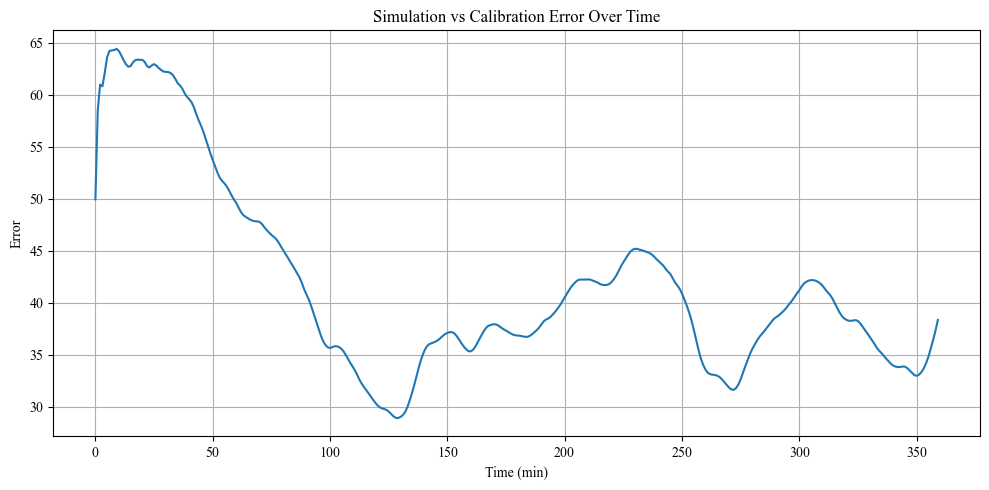

In [33]:
# plot error over time between prediction and simulation
p = Plotter(1, 1)
p[0].plot(np.abs(v_plot_pred - v_sim[0:-1, :]).mean(axis=1))
p[0] = {'xlabel': 'Time (min)', 'ylabel': 'Error', 'title': 'Simulation vs Calibration Error Over Time'}
p[0].grid()
# p.savefig(RESULTS_DIR / 'error_propogate_lanes_ramping.png')
p.show()

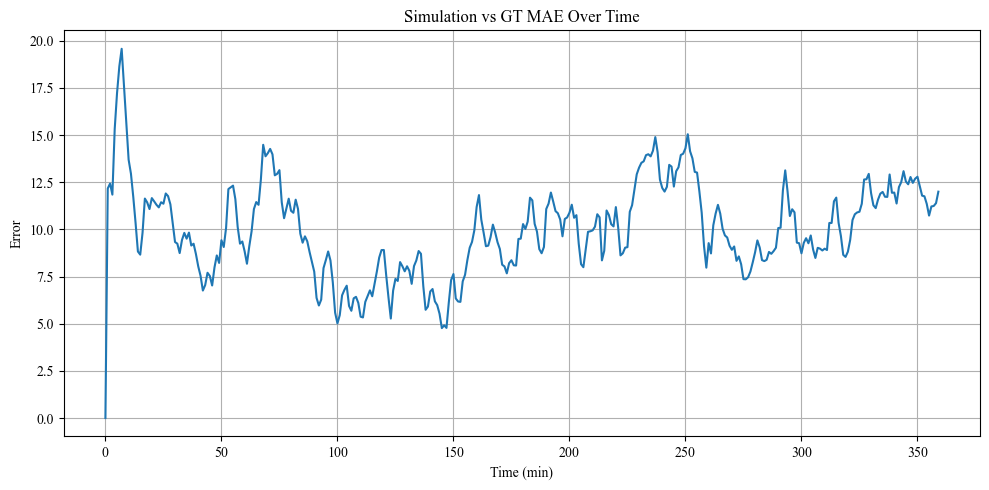

In [34]:
# plot error over time between prediction and simulation
p = Plotter(1, 1)
p[0].plot(np.abs(v_hat[:, 1:-1] - v_sim[0:-1, :]).mean(axis=1))
p[0] = {'xlabel': 'Time (min)', 'ylabel': 'Error', 'title': 'Simulation vs GT MAE Over Time'}
p[0].grid()
# p.savefig(RESULTS_DIR / 'error_propogate_lanes_ramping.png')
p.show()

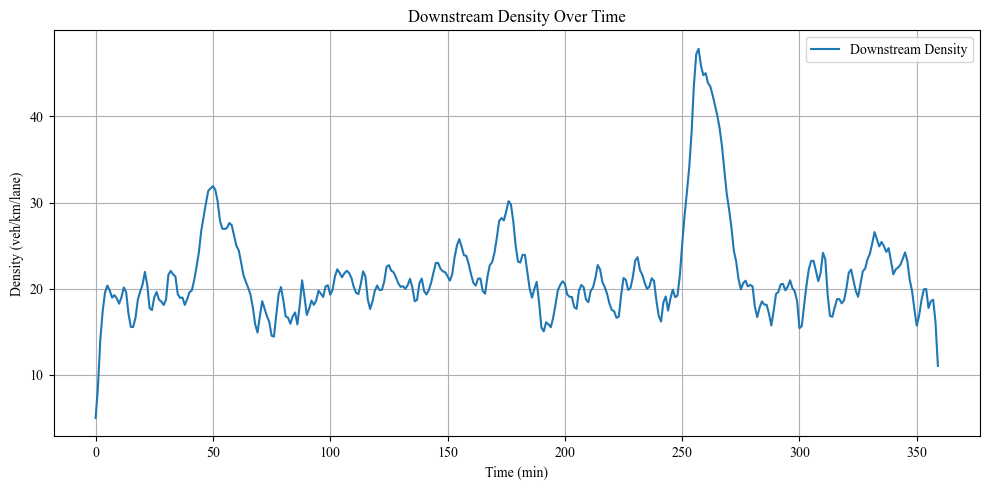

In [35]:
#plot downstream density over time and inflow over time
p = Plotter(1, 1)
p[0].plot(downstream_density, label='Downstream Density')
p[0] = {'xlabel': 'Time (min)', 'ylabel': 'Density (veh/km/lane)', 'title': 'Downstream Density Over Time'}
p[0].grid()
p.show()

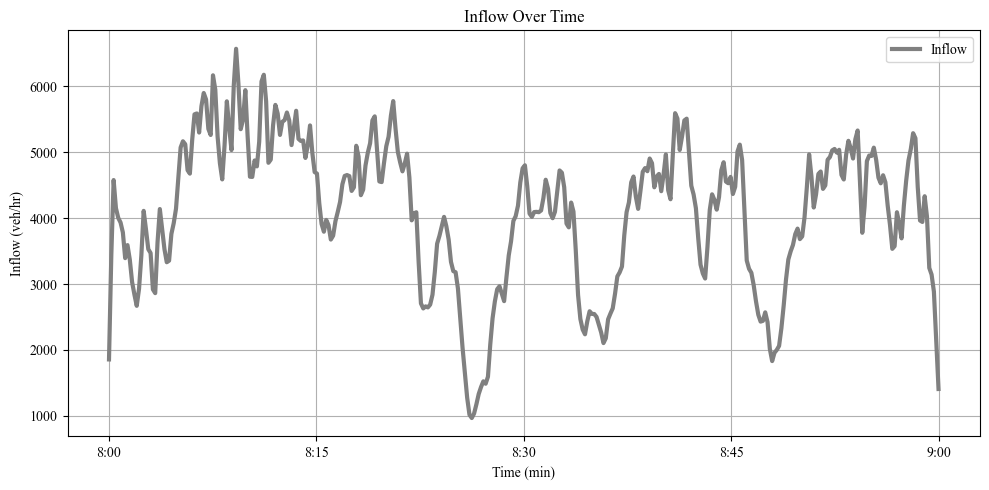

In [36]:
# Plot inflow over time
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# g_fontsize = 21
# mpl.rcParams.update({
#     "font.family": "serif",
#     "font.serif": "Times New Roman",
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
#     "mathtext.fontset": "cm",
#     "axes.unicode_minus": False,
#     "text.usetex": False,
#     "font.size": g_fontsize,
#     "axes.labelsize": g_fontsize,
#     "xtick.labelsize": g_fontsize - 2,
#     "ytick.labelsize": g_fontsize - 2,
#     "legend.fontsize": g_fontsize - 1,
# })

# Assume data_inflow covers exactly 8:00 AM to 9:00 AM
n = len(data_inflow)

tick_positions = np.linspace(0, n - 1, 5)
tick_labels = ['8:00', '8:15', '8:30', '8:45', '9:00']

p = Plotter(1, 1)
p[0].plot(data_inflow, label='Inflow', linewidth=3, color='gray')
p[0] = {'title': 'Inflow Over Time', 'xlabel': 'Time (min)', 'ylabel': 'Inflow (veh/hr)',
        'xticks': tick_positions, 'xticklabels': tick_labels}
p[0].grid()
# p.savefig('inflow_over_time.pdf', bbox_inches='tight')
p.show()

Pred shape: (360, 14)
True shape: (360, 14)
Max true density: 8091.98009999998


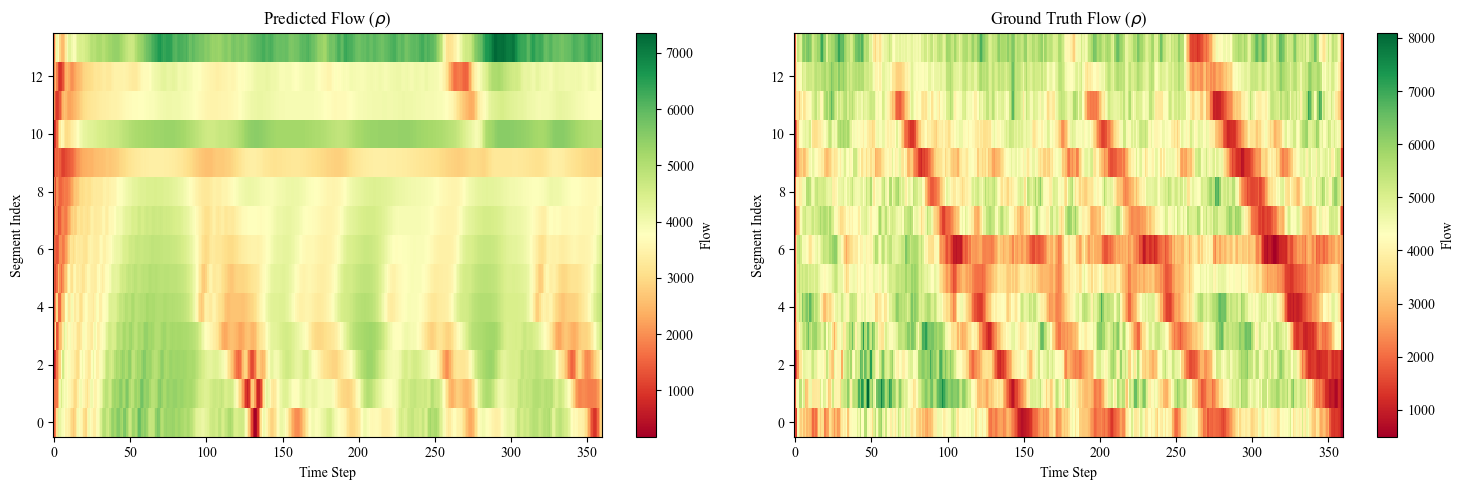

In [37]:
rho_plot_pred = rho_pred_array * v_pred_array
rho_plot_true = q_hat[:, 1:-1]

print("Pred shape:", rho_plot_pred.shape)
print("True shape:", rho_plot_true.shape)
print("Max true density:", np.max(rho_plot_true))

p = Plotter(1, 2)
p.fig.colorbar(p[0].imshow(rho_plot_pred.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"), ax=p[0], label="Flow")
p.fig.colorbar(p[1].imshow(rho_plot_true.T, aspect="auto", origin="lower", cmap="RdYlGn", interpolation="none"), ax=p[1], label="Flow")
p[0] = {'title': 'Predicted Flow ($\\rho$)', 'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
p[1] = {'title': 'Ground Truth Flow ($\\rho$)', 'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
p.show()

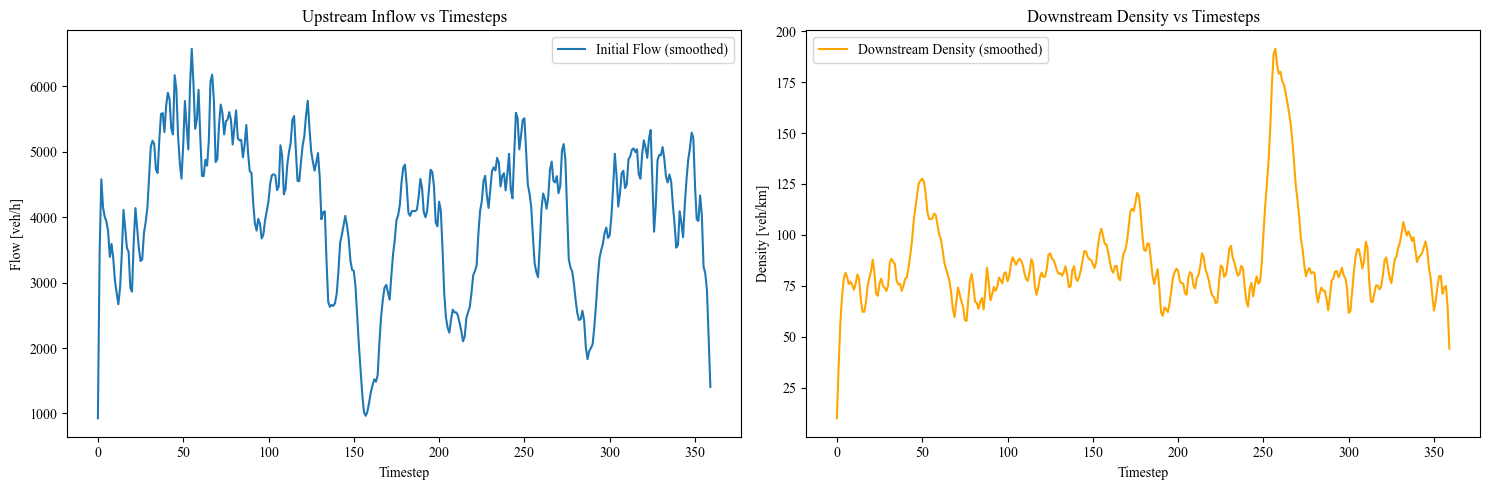

In [38]:
from scipy.ndimage import uniform_filter1d
def smooth_inflow(inflow, window_size=2):
    return uniform_filter1d(inflow, size=window_size, axis=0, mode="constant", cval=0.0, output=np.float64)

# Example input arrays (replace with your real q_hat and rho_hat)
# timesteps = 100
# q_hat = np.random.uniform(500, 1000, size=(timesteps, 5))   # flow [veh/h]
# rho_hat = np.random.uniform(10, 50, size=(timesteps, 5))    # density [veh/km]

# Apply smoothing
initial_flow = smooth_inflow(q_hat[:, 0:1])  # upstream inflow
downstream_density = smooth_inflow(p_hat[:, -1:])  # downstream density

# Plotting
p = Plotter(1, 2)
p[0].plot(initial_flow, label="Initial Flow (smoothed)")
p[1].plot(downstream_density, color="orange", label="Downstream Density (smoothed)")
p[0] = {'xlabel': "Timestep", 'ylabel': "Flow [veh/h]", 'title': "Upstream Inflow vs Timesteps"}
p[1] = {'xlabel': "Timestep", 'ylabel': "Density [veh/km]", 'title': "Downstream Density vs Timesteps"}
p.show()

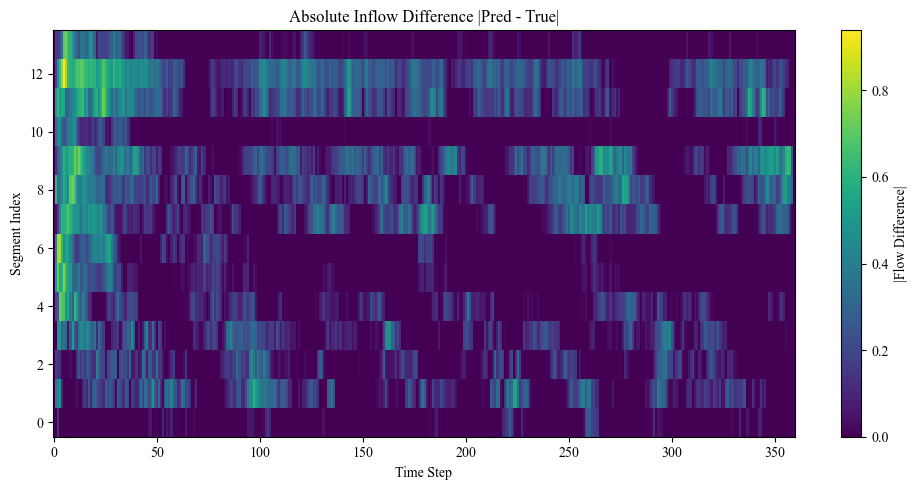

In [39]:
def get_velocity_heatmap(v_hat, v_pred, q_hat, q_pred, rho_hat, rho_pred):
    shortened_v_hat = v_hat[:, 1:-1]
    shortened_rho_hat = rho_hat[:, 1:-1]
    shortened_q_hat = q_hat[:, 1:-1]
    # Determine some set of 3 scalars for each of q, rho, v to make a unified map
    v_diff = (shortened_v_hat - v_pred) / np.max(shortened_v_hat)
    rho_diff = (shortened_rho_hat - rho_pred) / np.max(shortened_rho_hat)
    q_diff = (shortened_q_hat - q_pred) / np.max(shortened_q_hat)

    diff = v_diff + rho_diff + q_diff

    p = Plotter(1, 1)
    p.fig.colorbar(p[0].imshow(diff.T, aspect="auto", origin="lower", cmap="viridis", interpolation="none", vmin=0), ax=p[0], label="|Flow Difference|")
    p[0] = {'title': 'Absolute Inflow Difference |Pred - True|', 'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
    p.show()


get_velocity_heatmap(v_hat, v_pred_array, q_hat, q_array, p_hat, rho_pred_array)